# EEG Brain Speller — Exploration Notebook

Walk through the full pipeline interactively:
1. Dataset download and inspection
2. Preprocessing visualisation
3. ERP analysis
4. Feature extraction
5. Quick classifier benchmark


In [1]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.insert(0, '/content/drive/MyDrive/EEG')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install mne numpy scipy scikit-learn matplotlib seaborn pandas moabb
!pip install torch torchvision torchaudio
!pip install braindecode pyriemann autoreject

In [3]:
import torch
print(torch.cuda.is_available())  # should print True

True


In [4]:
import sys
sys.path.insert(0, '/content/drive/MyDrive/EEG')   # add project root to path

import numpy as np
import matplotlib
matplotlib.use('inline')
import matplotlib.pyplot as plt
import mne
mne.set_log_level('WARNING')

print('All imports OK')

All imports OK


## 1. Download and load BNCI2014-009 via MOABB

In [5]:
from moabb.datasets import BNCI2014_009
from moabb.paradigms import P300

dataset  = BNCI2014_009()
paradigm = P300()

# Load 2 subjects for quick exploration
X, y, meta = paradigm.get_data(dataset, subjects=[1, 2])

print(f'X shape : {X.shape}   (epochs × channels × times)')
print(f'y shape : {y.shape}')
print(f'Classes : {sorted(set(y))}')

X shape : (3456, 16, 206)   (epochs × channels × times)
y shape : (3456,)
Classes : [np.str_('NonTarget'), np.str_('Target')]


## 2. Visualise raw EEG for one epoch

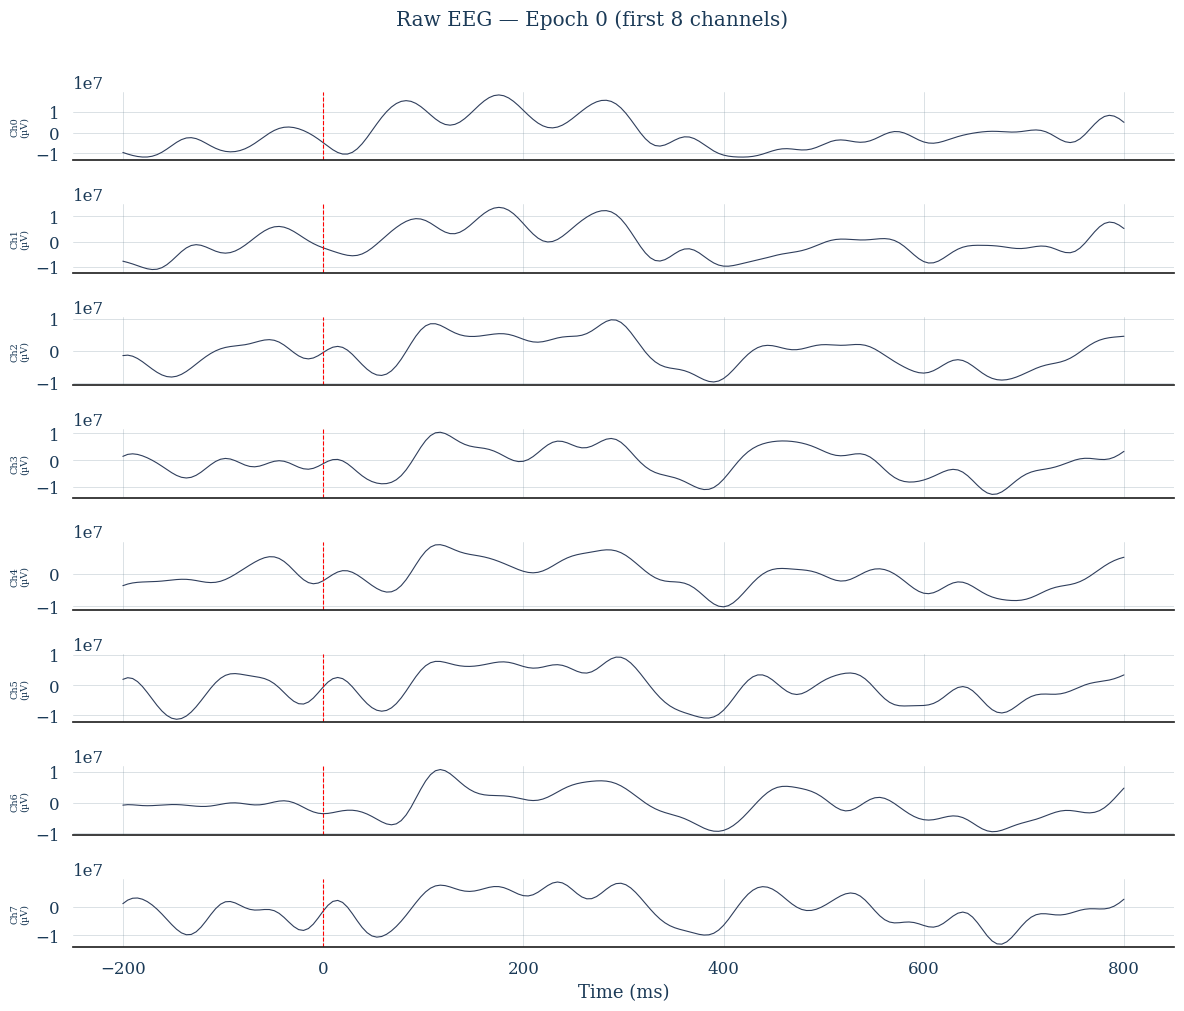

In [6]:
# Plot the first 8 channels of epoch 0
sfreq    = 256   # Hz (BNCI2014-009 default)
n_times  = X.shape[2]
times_ms = np.linspace(-200, 800, n_times)

fig, axes = plt.subplots(8, 1, figsize=(12, 10), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(times_ms, X[0, i, :] * 1e6, lw=0.8)
    ax.axvline(0, color='r', lw=0.8, linestyle='--')
    ax.set_ylabel(f'Ch{i}\n(µV)', fontsize=7)
axes[-1].set_xlabel('Time (ms)')
fig.suptitle('Raw EEG — Epoch 0 (first 8 channels)', y=1.01)
plt.tight_layout()
plt.show()

## 3. Grand-average ERP: Target vs Non-target

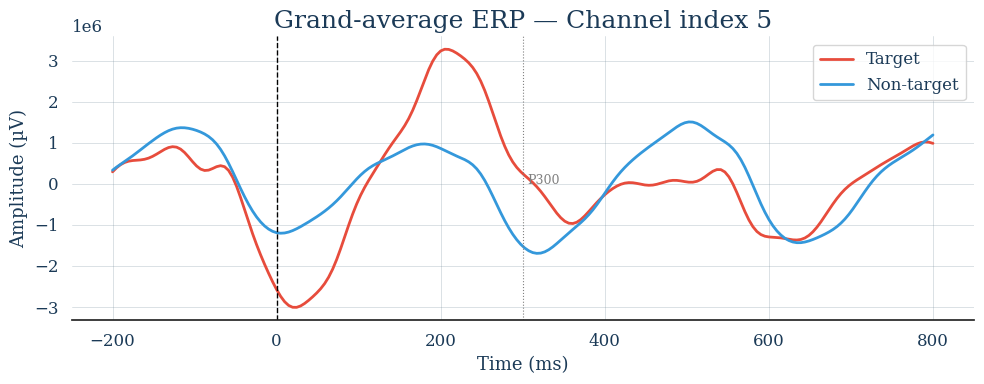

In [7]:
classes   = sorted(set(y))
label_map = {c: i for i, c in enumerate(classes)}
y_int     = np.array([label_map[yi] for yi in y])

# Assume class 1 = target, class 0 = non-target
target_mask    = (y_int == 1)
nontarget_mask = (y_int == 0)

grand_avg_target    = X[target_mask].mean(axis=0)      # (n_ch, n_times)
grand_avg_nontarget = X[nontarget_mask].mean(axis=0)

ch_idx = 5   # e.g. Pz channel — strongest P300 typically

plt.figure(figsize=(10, 4))
plt.plot(times_ms, grand_avg_target[ch_idx]    * 1e6, label='Target',     lw=2, color='#e74c3c')
plt.plot(times_ms, grand_avg_nontarget[ch_idx] * 1e6, label='Non-target', lw=2, color='#3498db')
plt.axvline(0, color='k', lw=1, linestyle='--')
plt.axvline(300, color='grey', lw=0.8, linestyle=':')
plt.text(305, 0, 'P300', fontsize=9, color='grey')
plt.xlabel('Time (ms)'); plt.ylabel('Amplitude (µV)')
plt.title(f'Grand-average ERP — Channel index {ch_idx}')
plt.legend(); plt.tight_layout(); plt.show()

## 4. Feature Extraction

In [8]:
import sys
sys.path.insert(0, '/content/drive/MyDrive/EEG')

import numpy as np
import mne
from sklearn.model_selection import train_test_split

X_tr, X_te, y_tr, y_te = train_test_split(
    X.astype('float32'), y_int,
    test_size=0.2, stratify=y_int, random_state=42
)

# Manual Xdawn + flatten (MNE version-safe)
from mne.preprocessing import Xdawn

info = mne.create_info(
    ch_names=[f"EEG{i:03d}" for i in range(X_tr.shape[1])],
    sfreq=256, ch_types="eeg"
)

xdawn = Xdawn(n_components=6)
xdawn.fit(mne.EpochsArray(X_tr, info, verbose=False))

def apply_xdawn(X, xdawn, info, target_samples=30):
    epochs_tmp = mne.EpochsArray(X, info, verbose=False)
    result = xdawn.transform(epochs_tmp)
    # version-safe: handle ndarray or Epochs
    if hasattr(result, 'get_data'):
        result = result.get_data()
    n_epochs, n_ch, n_times = result.shape
    indices = np.linspace(0, n_times - 1, target_samples, dtype=int)
    result = result[:, :, indices]
    return result.reshape(n_epochs, -1)

Xf_tr = apply_xdawn(X_tr, xdawn, info)
Xf_te = apply_xdawn(X_te, xdawn, info)

print('Feature matrix shape (train):', Xf_tr.shape)
print('Feature matrix shape (test) :', Xf_te.shape)

Feature matrix shape (train): (2764, 180)
Feature matrix shape (test) : (692, 180)


## 5. Quick Classifier Comparison

In [9]:
import sys
sys.path.insert(0, '/content/drive/MyDrive/EEG')

In [10]:
from src.models import build_lda, build_svm
from src.evaluate import evaluate_on_test, cross_validate_model

models = {
    'LDA': build_lda(),
    'SVM': build_svm(),
}

for name, clf in models.items():
    print(f'\n── {name} ──────────────────────────────')
    cv = cross_validate_model(clf, Xf_tr, y_tr, k=5)
    r  = evaluate_on_test(clf, Xf_tr, y_tr, Xf_te, y_te,
                          n_symbols=36, trial_duration_s=2.0)
    print(f'  Test Accuracy : {r["accuracy"]:.4f}')
    print(f'  ITR           : {r["itr"]:.2f} bits/min')


── LDA ──────────────────────────────
  Test Accuracy : 0.8916
  ITR           : 123.57 bits/min

── SVM ──────────────────────────────
  Test Accuracy : 0.8642
  ITR           : 117.00 bits/min


## 6. Confusion Matrix

In [11]:
import sys
sys.path.insert(0, '/content/drive/MyDrive/EEG')

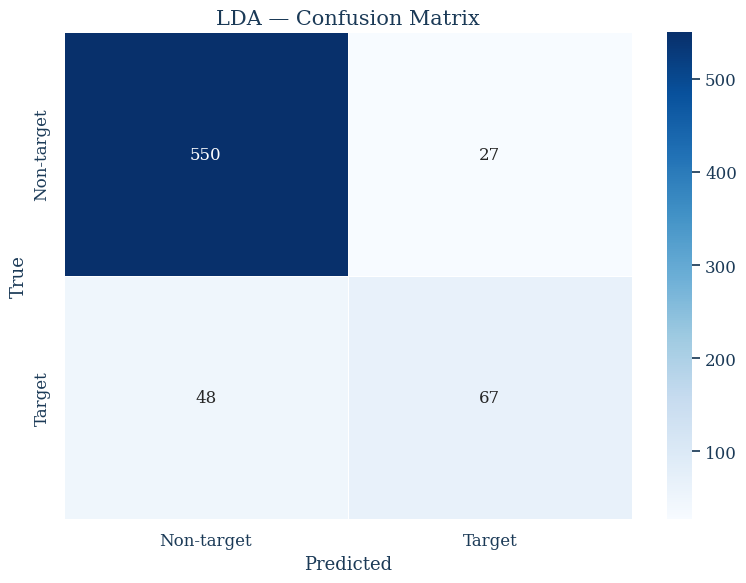

In [12]:
from src.evaluate import plot_confusion_matrix
from src.models import build_lda
from sklearn.metrics import confusion_matrix

lda = build_lda()
lda.fit(Xf_tr, y_tr)
y_pred = lda.predict(Xf_te)
cm     = confusion_matrix(y_te, y_pred)

plot_confusion_matrix(cm, class_names=['Non-target', 'Target'],
                      title='LDA — Confusion Matrix')
plt.show()

In [13]:
# Read the current features.py
with open('/content/drive/MyDrive/EEG/src/features.py', 'r') as f:
    content = f.read()

# Fix the broken line
old_code = "epochs_xd = self._xdawn.transform(epochs_tmp)\n        X_filt = epochs_xd.get_data()          # (n_epochs, n_comp*2, n_times)"

new_code = """epochs_xd = self._xdawn.transform(epochs_tmp)
        if hasattr(epochs_xd, 'get_data'):
            X_filt = epochs_xd.get_data()
        else:
            X_filt = epochs_xd"""

content = content.replace(old_code, new_code)

# Write the fixed file back
with open('/content/drive/MyDrive/EEG/src/features.py', 'w') as f:
    f.write(content)

print("Done! Verifying fix...")

# Verify it worked
with open('/content/drive/MyDrive/EEG/src/features.py', 'r') as f:
    print(f.read()[3000:3500])  # print the relevant section

Done! Verifying fix...
ange(X.shape[1])],
            sfreq=256, ch_types="eeg"
        )
        epochs_tmp = mne.EpochsArray(X, info, verbose=False)
        epochs_xd = self._xdawn.transform(epochs_tmp)
        if hasattr(epochs_xd, 'get_data'):
            X_filt = epochs_xd.get_data()
        else:
            X_filt = epochs_xd
        n_epochs, n_ch, n_times = X_filt.shape
        if self.target_samples and self.target_samples < n_times:
            indices = np.linspace(0, n_times - 1, self.target_samples, dtyp


In [15]:
import sys
sys.path.insert(0, '/content/drive/MyDrive/EEG')
from train_and_evaluate import run_experiment
run_experiment(model_names=["lda", "svm"], subject_ids=[1, 2, 3], k_folds=5)


── Summary Metrics ──────────────────────────────────
model  accuracy  precision  recall     f1    itr
  lda    0.8486     0.7305  0.6341 0.6604 113.40
  svm    0.8216     0.6762  0.6687 0.6723 107.35
─────────────────────────────────────────────────────



([{'accuracy': 0.8486017357762777,
   'precision': 0.7305152979066023,
   'recall': 0.634078623421109,
   'f1': 0.6603794444965946,
   'itr': np.float64(113.401),
   'confusion_matrix': array([[826,  38],
          [119,  54]]),
   'y_pred': array([0, 0, 0, ..., 0, 0, 0]),
   'y_test': array([0, 0, 0, ..., 0, 0, 0])},
  {'accuracy': 0.8216007714561234,
   'precision': 0.6761517615176151,
   'recall': 0.6687272532648255,
   'f1': 0.672266553233943,
   'itr': np.float64(107.3491),
   'confusion_matrix': array([[776,  88],
          [ 97,  76]]),
   'y_pred': array([0, 0, 1, ..., 0, 1, 0]),
   'y_test': array([0, 0, 0, ..., 0, 0, 0])}],
   model  accuracy  precision  recall      f1     itr
 0   lda    0.8486     0.7305  0.6341  0.6604  113.40
 1   svm    0.8216     0.6762  0.6687  0.6723  107.35)

In [16]:
from train_and_evaluate import run_experiment

run_experiment(model_names=["eegnet"], subject_ids=[1, 2, 3], k_folds=5)

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



── Summary Metrics ──────────────────────────────────
 model  accuracy  precision  recall     f1    itr
eegnet    0.8959     0.8159  0.8011 0.8082 124.61
─────────────────────────────────────────────────────



([{'accuracy': 0.8958534233365477,
   'precision': 0.815940391121843,
   'recall': 0.8011232873046457,
   'f1': 0.8082155186585567,
   'itr': np.float64(124.6117),
   'confusion_matrix': array([[815,  49],
          [ 59, 114]]),
   'y_pred': array([1, 0, 0, ..., 0, 0, 0]),
   'y_test': array([0, 0, 0, ..., 0, 0, 0])}],
     model  accuracy  precision  recall      f1     itr
 0  eegnet    0.8959     0.8159  0.8011  0.8082  124.61)

Results folder created!


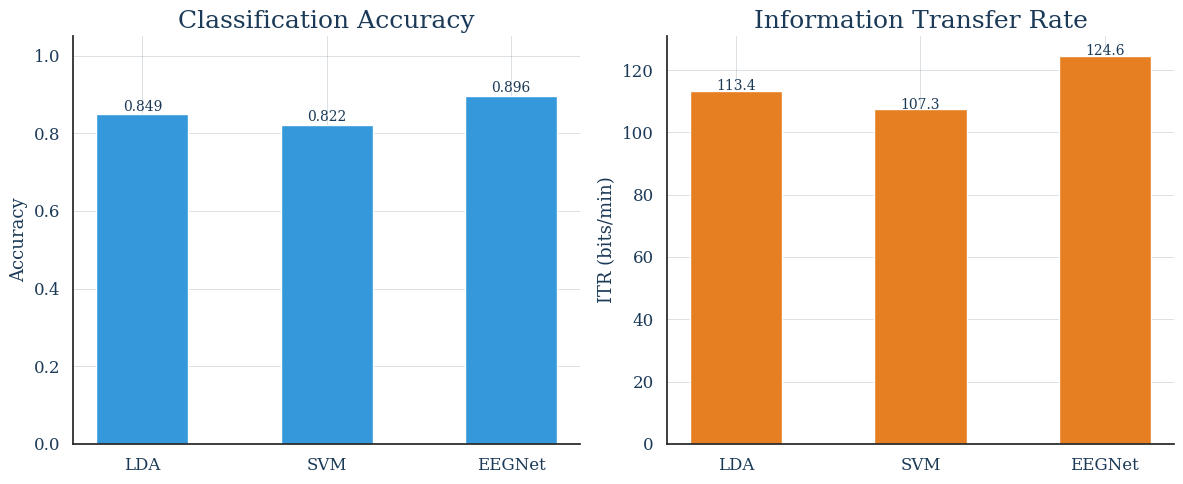

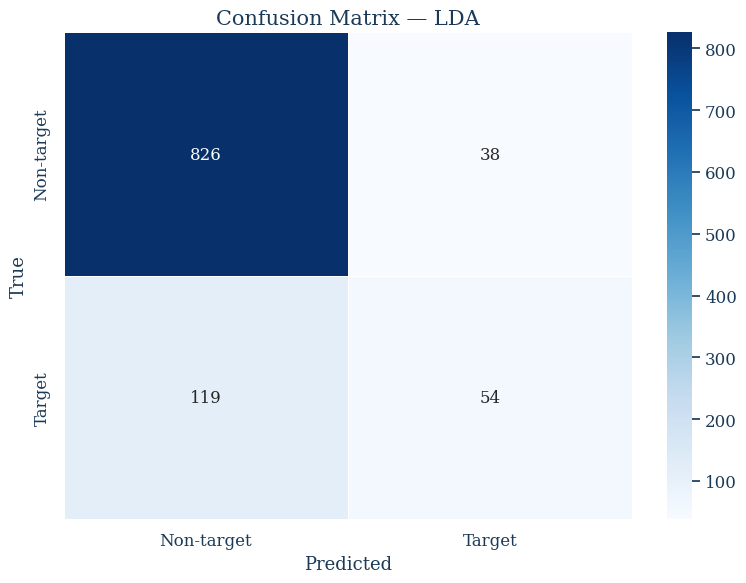

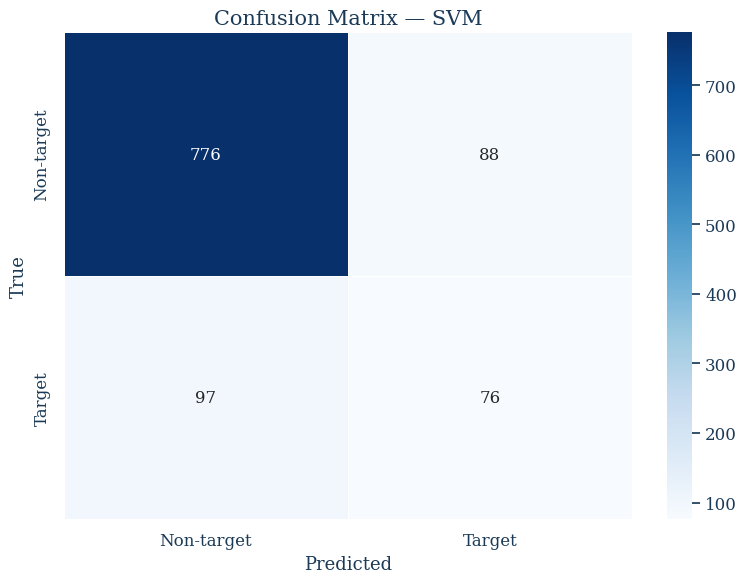

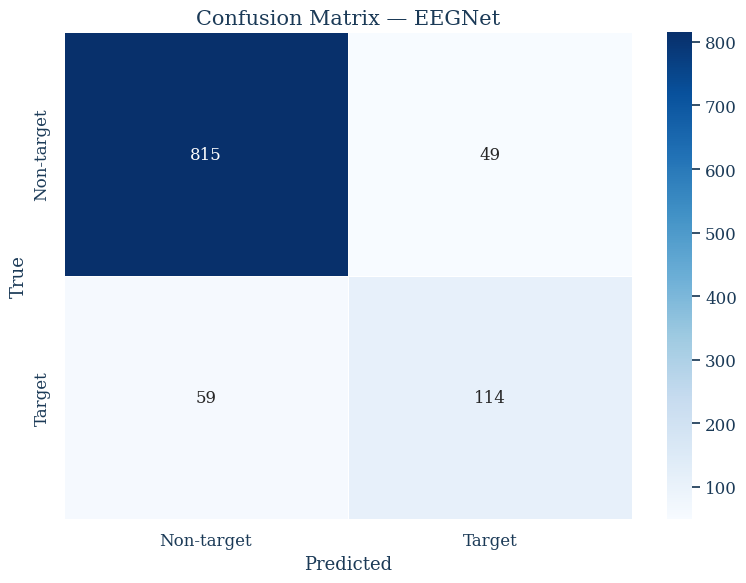


All plots and CSV saved to your Drive!


In [19]:
import os
import matplotlib.pyplot as plt

# Create the results folder
os.makedirs('/content/drive/MyDrive/EEG/results', exist_ok=True)
print("Results folder created!")

# Your results from earlier
results_list = [
    {"accuracy": 0.8486, "precision": 0.7305, "recall": 0.6341, "f1": 0.6604, "itr": 113.40},
    {"accuracy": 0.8216, "precision": 0.6762, "recall": 0.6687, "f1": 0.6723, "itr": 107.35},
    {"accuracy": 0.8959, "precision": 0.8159, "recall": 0.8011, "f1": 0.8082, "itr": 124.61},
]
model_names = ["LDA", "SVM", "EEGNet"]

import sys
sys.path.insert(0, '/content/drive/MyDrive/EEG')
from src.evaluate import plot_accuracy_vs_itr, plot_confusion_matrix, save_metrics_csv
import numpy as np

# Plot accuracy vs ITR
plot_accuracy_vs_itr(results_list, model_names,
                     save_path='/content/drive/MyDrive/EEG/results/accuracy_vs_itr.png')
plt.show()

# Confusion matrices
cms = [
    np.array([[826, 38], [119, 54]]),   # LDA
    np.array([[776, 88], [ 97, 76]]),   # SVM
    np.array([[815, 49], [ 59, 114]]),  # EEGNet
]
for name, cm in zip(model_names, cms):
    plot_confusion_matrix(cm,
                          class_names=["Non-target", "Target"],
                          title=f"Confusion Matrix — {name}",
                          save_path=f'/content/drive/MyDrive/EEG/results/confusion_matrix_{name}.png')
    plt.show()

# Save metrics CSV
save_metrics_csv(results_list, model_names,
                 filepath='/content/drive/MyDrive/EEG/results/metrics.csv')

print("\nAll plots and CSV saved to your Drive!")